<a href="https://colab.research.google.com/github/Mukhidinov2006/E-commerce-Analysis/blob/main/Project(E_com).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Sample Dataset(E-commmerce)
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

np.random.seed(42)

n = 1000

cities = ['Tashkent', 'Samarkand', 'Bukhara', 'Andijan', 'Namangan']
categories = ['Electronics', 'Clothing', 'Home', 'Sports', 'Beauty']
payments = ['card', 'cash', 'Card', 'CASH', 'online', None]
genders = ['Male', 'Female', 'M', 'F', None]

def random_date(start, end):
    return start + timedelta(days=random.randint(0, (end - start).days))

data = []

for i in range(n):
    signup = random_date(datetime(2020,1,1), datetime(2023,12,31))
    last_purchase = signup + timedelta(days=random.randint(0, 1000))

    row = {
        "customer_id": f"CUST{1000+i}",
        "age": random.choice([random.randint(18,70), None, 150]),  # bad values
        "gender": random.choice(genders),
        "city": random.choice(cities),
        "signup_date": random.choice([
            signup.strftime('%Y-%m-%d'),
            signup.strftime('%d/%m/%Y')
        ]),
        "last_purchase_date": last_purchase.strftime('%Y-%m-%d'),
        "purchase_amount": round(np.random.normal(100, 50), 2),
        "product_category": random.choice(categories),
        "payment_method": random.choice(payments),
        "is_returned": random.choice(['Yes', 'No', 'Y', 'N', None]),
        "rating": random.choice([1,2,3,4,5,None,10]),  # invalid rating
        "discount_applied": random.choice([0,5,10,20,None]),
        "order_id": f"ORD{random.randint(10000,99999)}",
        "delivery_days": random.choice([1,2,3,5,7,30,-2])  # anomalies
    }

    data.append(row)

df = pd.DataFrame(data)

# Save dataset
df.to_csv("ecommerce_dirty_dataset.csv", index=False)

print("Dataset created: ecommerce_dirty_dataset.csv")

Dataset created: ecommerce_dirty_dataset.csv


### **Data Cleaning**

In [ ]:
df.head()

,customer_id,age,gender,city,signup_date,last_purchase_date,purchase_amount,product_category,payment_method,is_returned,rating,discount_applied,order_id,delivery_days
0,CUST1000,150.0,M,Samarkand,22/12/2020,2021-02-13,124.84,Sports,CASH,Y,5.0,NaN,ORD66212,-2
1,CUST1001,NaN,None,Andijan,22/07/2021,2023-04-30,93.09,Clothing,CASH,N,10.0,5.0,ORD11672,5
2,CUST1002,150.0,Male,Namangan,2023-02-18,2025-04-20,132.38,Electronics,cash,Yes,4.0,10.0,ORD63574,-2
3,CUST1003,NaN,None,Tashkent,02/10/2023,2026-03-01,176.15,Clothing,Card,N,5.0,NaN,ORD23576,1
4,CUST1004,30.0,M,Samarkand,05/11/2020,2022-09-30,88.29,Home,CASH,Y,5.0,20.0,ORD53915,7


In [ ]:
#fixing age
df = df[(df['age'] >= 18) & (df['age'] <= 80)]
df['age'] = df['age'].fillna(df['age'].median())
print(df['age'])

4      30.0
8      35.0
9      53.0
21     63.0
22     63.0
       ... 
975    65.0
978    20.0
985    56.0
989    46.0
990    39.0
Name: age, Length: 325, dtype: float64


In [ ]:
#fixing  standardizing gender(NaN values remained)

gender_map = {'m': 'Male', 'f': 'Female', 'male': 'Male', 'female': 'Female'}
df['gender'] = df['gender'].str.lower().map(gender_map)
print(df['gender'])

4        Male
8      Female
9        Male
21     Female
22     Female
        ...  
975       NaN
978    Female
985      Male
989    Female
990      Male
Name: gender, Length: 325, dtype: object


In [ ]:
# clean payment_method
df['payment_method']=df['payment_method'].str.lower()
print(df['payment_method'])

4        cash
8        cash
9      online
21       cash
22     online
        ...  
975      card
978      cash
985      card
989      card
990      None
Name: payment_method, Length: 325, dtype: object


In [ ]:
#fixing is_returned
return_map = {'y': 1, 'n': 0, 'yes': 1, 'no': 0, None:0}
df['is_returned'] = df['is_returned'].str.lower().map(return_map)
print(df['is_returned'])

4      1
8      0
9      1
21     0
22     0
      ..
975    1
978    1
985    1
989    0
990    1
Name: is_returned, Length: 325, dtype: int64


In [ ]:
#fixing rate
df = df[(df['rating'] >= 1) & (df['rating'] <= 5)]
df['rating'] = df['rating'].fillna(df['rating'].median())
print(df['rating'])

4      5.0
21     4.0
22     5.0
24     1.0
29     1.0
      ... 
969    5.0
973    4.0
978    4.0
989    5.0
990    5.0
Name: rating, Length: 236, dtype: float64


In [ ]:
# converting date
df['signup_date'] = pd.to_datetime(df['signup_date'], errors='coerce')
df['last_purchase_date'] = pd.to_datetime(df['last_purchase_date'], errors='coerce')
df.head()

,customer_id,age,gender,city,signup_date,last_purchase_date,purchase_amount,product_category,payment_method,is_returned,rating,discount_applied,order_id,delivery_days
4,CUST1004,30.0,Male,Samarkand,2020-05-11,2022-09-30,88.29,Home,cash,1,5.0,20.0,ORD53915,7
21,CUST1021,63.0,Female,Samarkand,2022-06-08,2024-03-22,88.71,Beauty,cash,0,4.0,0.0,ORD12781,3
22,CUST1022,63.0,Female,Namangan,NaT,2024-07-09,103.38,Sports,online,0,5.0,5.0,ORD73370,3
24,CUST1024,54.0,Female,Namangan,NaT,2023-10-02,72.78,Clothing,card,0,1.0,20.0,ORD65466,-2
29,CUST1029,52.0,NaN,Tashkent,NaT,2024-05-03,85.42,Electronics,online,0,1.0,5.0,ORD72351,3


In [ ]:
#remmoving negative delivery_days
df = df[df['delivery_days']>0]
print(df['delivery_days'])


4       7
21      3
22      3
29      3
31     30
       ..
958     2
969    30
973    30
978    30
989     5
Name: delivery_days, Length: 199, dtype: int64


### **Product Performance Analysis**

In [ ]:
# Which category sells the most?
most_sold_category = df['product_category'].value_counts().reset_index()
most_sold_category.columns = ['product_category', 'number_of_sales']
print("Category with the most sales:")
display(most_sold_category)

Category with the most sales:


,product_category,number_of_sales
0,Electronics,45
1,Sports,40
2,Beauty,39
3,Home,38
4,Clothing,37


In [ ]:
# Which category generates the highest revenue?
highest_revenue_category = df.groupby('product_category')['purchase_amount'].sum().reset_index()
highest_revenue_category = highest_revenue_category.sort_values(by='purchase_amount', ascending=False)
print("Category generating the highest revenue:")
display(highest_revenue_category)

Category generating the highest revenue:


,product_category,purchase_amount
2,Electronics,4240.41
0,Beauty,4074.47
4,Sports,3930.02
1,Clothing,3871.46
3,Home,3834.38


In [ ]:
#Part 2     city generates the most revenue
df.groupby('city')['purchase_amount'].sum().sort_values(ascending=False)
df.head()

,customer_id,age,gender,city,signup_date,last_purchase_date,purchase_amount,product_category,payment_method,is_returned,rating,discount_applied,order_id,delivery_days
4,CUST1004,30.0,Male,Samarkand,2020-05-11,2022-09-30,88.29,Home,cash,1,5.0,20.0,ORD53915,7
21,CUST1021,63.0,Female,Samarkand,2022-06-08,2024-03-22,88.71,Beauty,cash,0,4.0,0.0,ORD12781,3
22,CUST1022,63.0,Female,Namangan,NaT,2024-07-09,103.38,Sports,online,0,5.0,5.0,ORD73370,3
29,CUST1029,52.0,NaN,Tashkent,NaT,2024-05-03,85.42,Electronics,online,0,1.0,5.0,ORD72351,3
31,CUST1031,33.0,Female,Samarkand,2022-09-09,2024-08-21,192.61,Beauty,card,1,5.0,NaN,ORD90302,30


### **Feature Engineering**

In [ ]:
# Before calculating customer_lifetime_days, ensure that signup_date and last_purchase_date are valid.
# Drop rows where either 'signup_date' or 'last_purchase_date' is NaT (Not a Time).
initial_row_count = len(df)
df = df.dropna(subset=['signup_date', 'last_purchase_date'])
rows_dropped = initial_row_count - len(df)
if rows_dropped > 0:
    print(f"Dropped {rows_dropped} rows due to invalid 'signup_date' or 'last_purchase_date'.")

df['customer_lifetime_days'] = (df['last_purchase_date'] - df['signup_date']).dt.days
df['high_value_customer'] = df['purchase_amount'] > df['purchase_amount'].median()
display(df[['customer_id', 'customer_lifetime_days', 'high_value_customer']].head())

Dropped 155 rows due to invalid 'signup_date' or 'last_purchase_date'.


,customer_id,customer_lifetime_days,high_value_customer
4,CUST1004,872,False
21,CUST1021,653,False
31,CUST1031,712,True
55,CUST1055,990,True
80,CUST1080,277,False


### **Returns Problem**

In [ ]:
# Calculate overall return rate
overall_return_rate = df['is_returned'].mean()
print(f"Overall Return Rate: {overall_return_rate:.2%}")

Overall Return Rate: 36.36%


In [ ]:
# Calculate return rate by product category
return_rate_by_category = df.groupby('product_category')['is_returned'].mean().reset_index()
return_rate_by_category.columns = ['product_category', 'return_rate']
return_rate_by_category = return_rate_by_category.sort_values(by='return_rate', ascending=False)

print("Return rate by product category:")
display(return_rate_by_category)

Return rate by product category:


,product_category,return_rate
4,Sports,0.500000
3,Home,0.500000
0,Beauty,0.461538
1,Clothing,0.250000
2,Electronics,0.111111


### **Discounts Effect**

In [ ]:
discount_effect = df.groupby('discount_applied')['purchase_amount'].mean().reset_index()
discount_effect.columns = ['discount_applied', 'average_purchase_amount']
print("Average purchase amount by discount applied:")
display(discount_effect)

Average purchase amount by discount applied:


,discount_applied,average_purchase_amount
0,0.0,121.65200
1,5.0,79.17300
2,10.0,108.18000
3,20.0,84.84125


### **Ratings Insight**

In [ ]:
# Which categories have the lowest ratings?
lowest_rated_categories = df.groupby('product_category')['rating'].mean().reset_index()
lowest_rated_categories = lowest_rated_categories.sort_values(by='rating', ascending= False)
lowest_rated_categories.columns = ['product_category', 'average_rating']

print("Categories with the highest average ratings:")
display(lowest_rated_categories)

Categories with the highest average ratings:


,product_category,average_rating
3,Home,3.750000
4,Sports,3.500000
0,Beauty,3.000000
1,Clothing,2.500000
2,Electronics,2.444444


In [ ]:
# Are low ratings linked to returns?
return_rate_by_rating = df.groupby('rating')['is_returned'].mean().reset_index()
return_rate_by_rating.columns = ['rating', 'return_rate']

print("Return rate by rating:")
display(return_rate_by_rating)

Return rate by rating:


,rating,return_rate
0,1.0,0.111111
1,2.0,0.444444
2,3.0,0.555556
3,4.0,0.285714
4,5.0,0.400000


### **ADVANCED ANALYSIS**

#### Cohort Analysis

In [ ]:
df['signup_year'] = df['signup_date'].dt.year
cohort_purchase_amount = df.groupby('signup_year')['purchase_amount'].mean().reset_index()
cohort_purchase_amount.columns = ['signup_year', 'average_purchase_amount']

print("Average purchase amount by signup year (cohort):")
display(cohort_purchase_amount)

Average purchase amount by signup year (cohort):


,signup_year,average_purchase_amount
0,2020,77.500000
1,2021,101.093750
2,2022,104.416000
3,2023,104.463636


#### Customer Segmentation

In [ ]:
df['purchase_amount_segment'] = pd.qcut(
    df['purchase_amount'],
    q=3, # Three segments: low, medium, high
    labels=['Low Spenders', 'Medium Spenders', 'High Spenders']
)

print("Distribution of customer segments based on purchase amount:")
display(df['purchase_amount_segment'].value_counts().reset_index())

Distribution of customer segments based on purchase amount:


,purchase_amount_segment,count
0,Low Spenders,15
1,High Spenders,15
2,Medium Spenders,14


### **Visualizations**

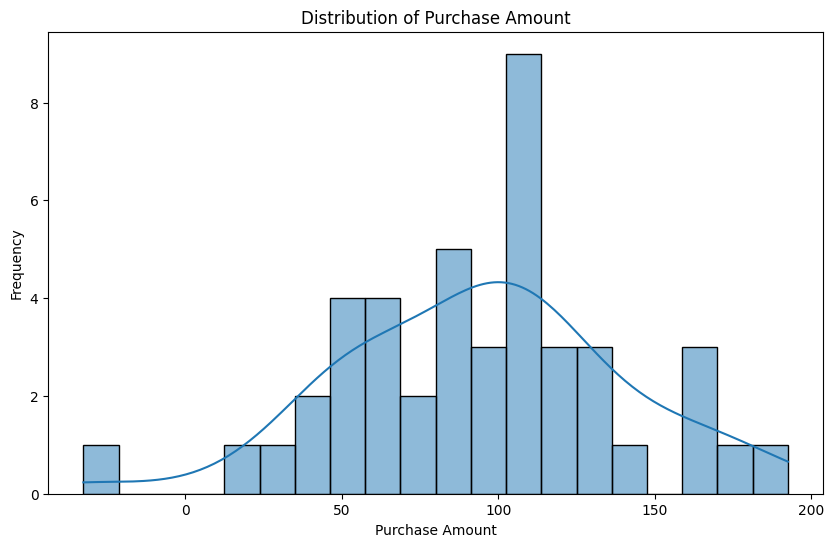

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram for purchase distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['purchase_amount'], bins=20, kde=True)
plt.title('Distribution of Purchase Amount')
plt.xlabel('Purchase Amount')
plt.ylabel('Frequency')
plt.show()

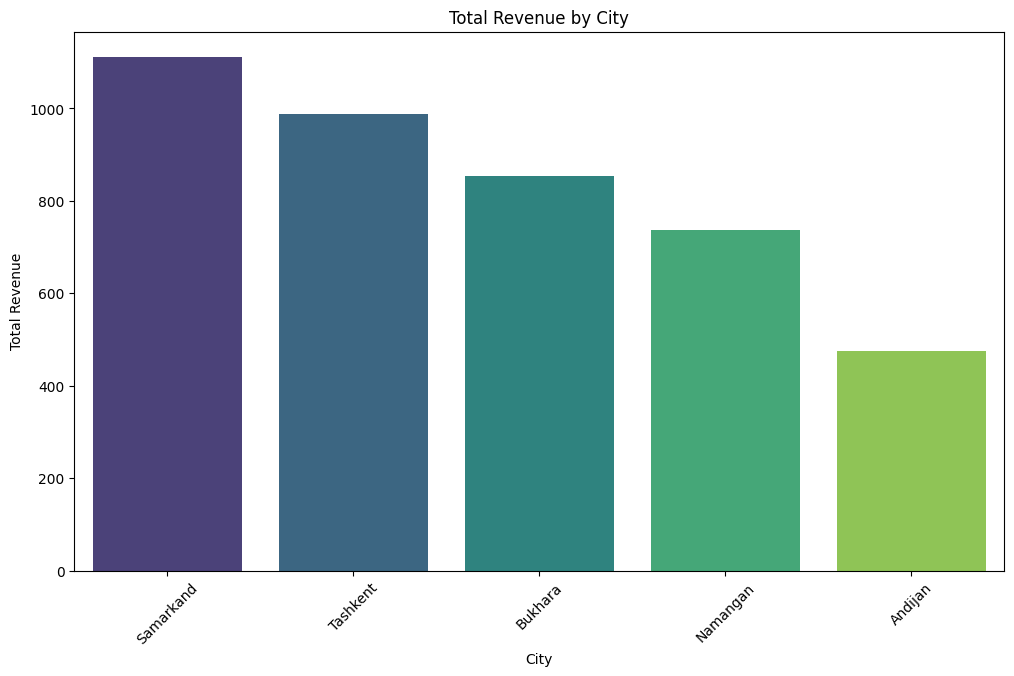

In [ ]:
# Bar chart for revenue by city
revenue_by_city = df.groupby('city')['purchase_amount'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='city', y='purchase_amount', hue='city', data=revenue_by_city, palette='viridis', legend=False)
plt.title('Total Revenue by City')
plt.xlabel('City')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

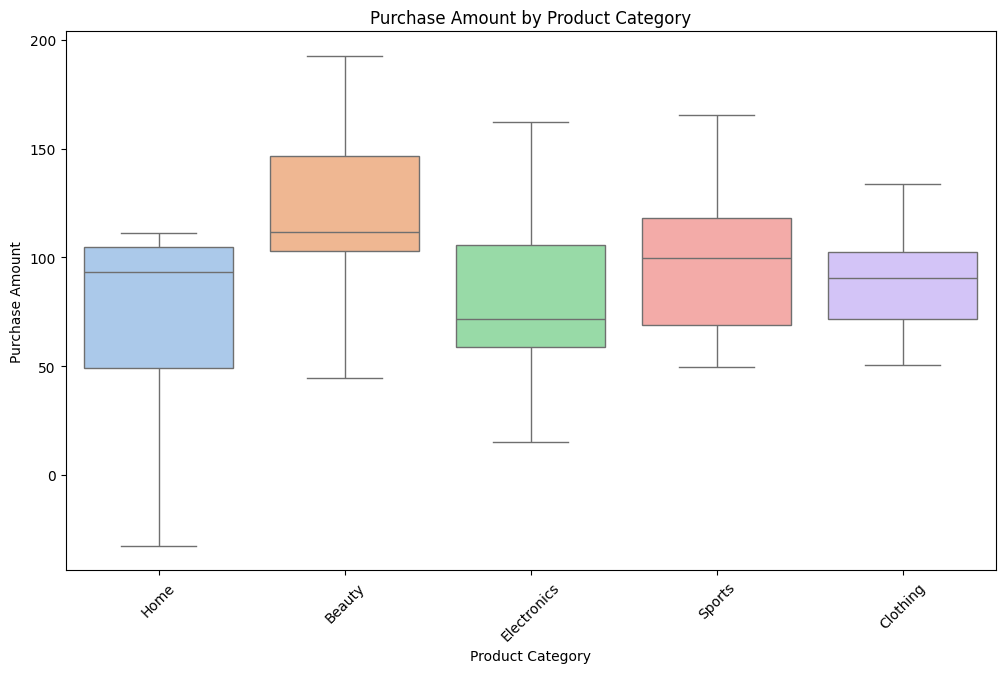

In [ ]:
# Boxplot for category vs purchase_amount
plt.figure(figsize=(12, 7))
sns.boxplot(x='product_category', y='purchase_amount', hue='product_category', data=df, palette='pastel', legend=False)
plt.title('Purchase Amount by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Purchase Amount')
plt.xticks(rotation=45)
plt.show()

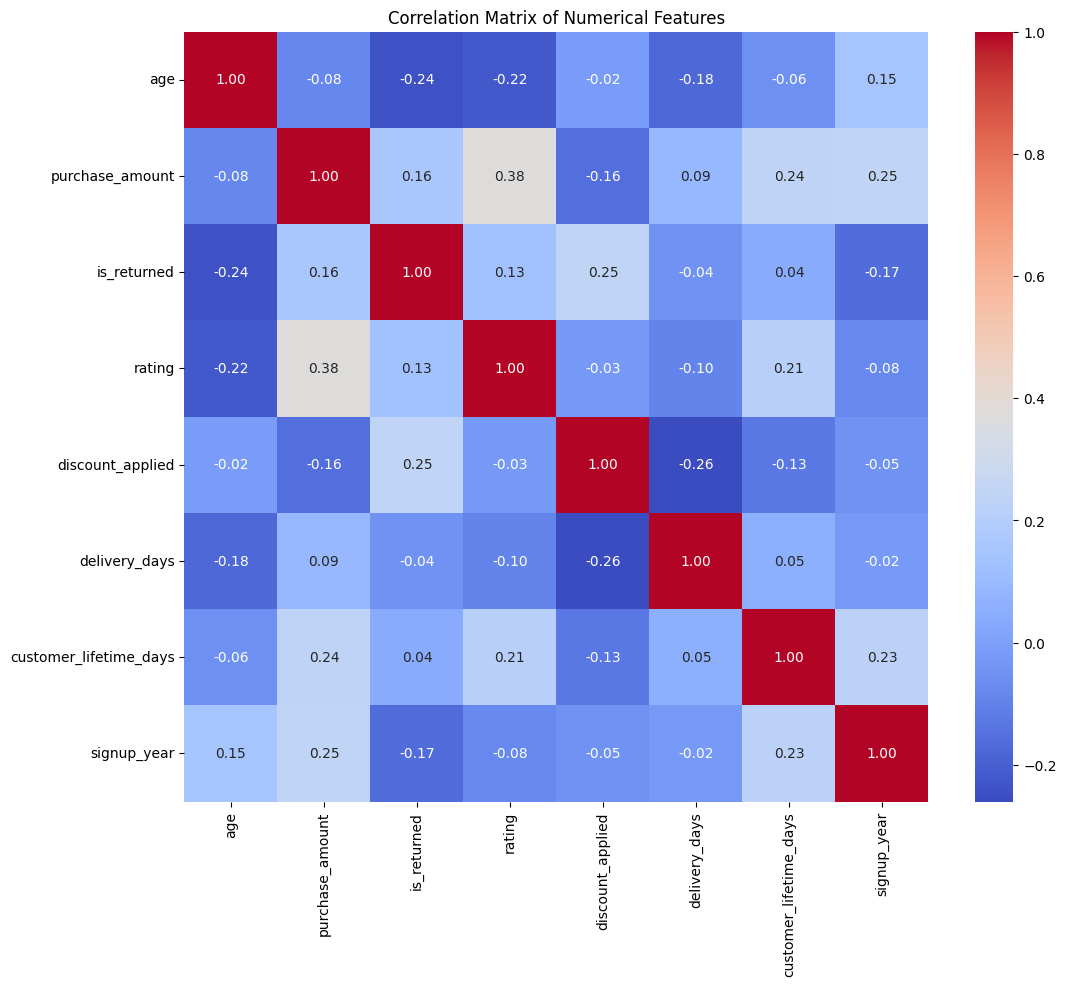

In [ ]:
# Heatmap for correlations
# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=['number'])
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()